<a href="https://colab.research.google.com/github/Shikta2003/Temperature-change-point-detection-and-forecasting/blob/main/temperature_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("kolkata_dailytemp.csv",encoding='latin1')
data.head()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,PRCP,PRCP_ATTRIBUTES,TAVG,TAVG_ATTRIBUTES,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES
0,IN024140300,"CALCUTTA ALIPORE, IN",22.533,88.333,6,07-12-2015,NaN,NaN,72,"H,,S",83.0,",,S",NaN,NaN
1,IN024140300,"CALCUTTA ALIPORE, IN",22.533,88.333,6,08-12-2015,NaN,NaN,73,"H,,S",83.0,",,S",NaN,NaN
2,IN024140300,"CALCUTTA ALIPORE, IN",22.533,88.333,6,09-12-2015,NaN,NaN,73,"H,,S",83.0,",,S",66.0,",,S"
3,IN024140300,"CALCUTTA ALIPORE, IN",22.533,88.333,6,10-12-2015,NaN,NaN,74,"H,,S",84.0,",,S",66.0,",,S"
4,IN024140300,"CALCUTTA ALIPORE, IN",22.533,88.333,6,11-12-2015,NaN,NaN,76,"H,,S",84.0,",,S",69.0,",,S"


In [3]:
# Remove unwanted columns
data = data.drop(columns=['STATION', 'NAME', 'LATITUDE', 'LONGITUDE','ELEVATION','PRCP_ATTRIBUTES','TAVG_ATTRIBUTES',
'TMAX_ATTRIBUTES','TMIN_ATTRIBUTES','TMAX','TMIN','PRCP'], errors='ignore')
# changing the unit of temperature from Fahrenheit to Celcius
data['TAVG'] = (data['TAVG'] - 32) * 5/9
data.head()

,DATE,TAVG
0,07-12-2015,22.222222
1,08-12-2015,22.777778
2,09-12-2015,22.777778
3,10-12-2015,23.333333
4,11-12-2015,24.444444


In [4]:
# Fix Date + Sort Data
data['DATE'] = pd.to_datetime(data['DATE'], format='%d-%m-%Y')
data = data.sort_values('DATE')
data = data.reset_index(drop=True)
data.head()

,DATE,TAVG
0,1980-01-01,20.000000
1,1980-01-02,18.888889
2,1980-01-03,19.444444
3,1980-01-04,18.888889
4,1980-01-05,18.333333


In [5]:
# Handle Missing Values
print(data.isna().sum())

# Interpolate (best for time series)
data[['TAVG']] = data[['TAVG']].interpolate()

DATE    0
TAVG    0
dtype: int64


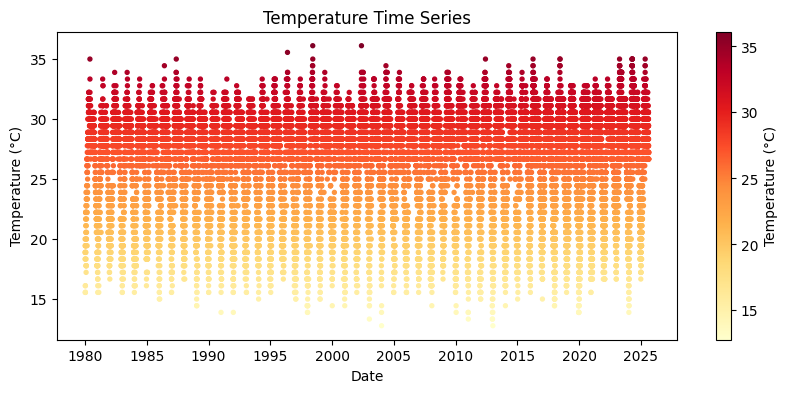

In [6]:
plt.figure(figsize=(10,4))

sc = plt.scatter(
    data['DATE'],
    data['TAVG'],
    c=data['TAVG'],          # color based on temperature
    cmap='YlOrRd',         # Yellow → Orange → Red
    s=8
)

plt.colorbar(sc, label='Temperature (°C)')

plt.title("Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.show()

In [7]:
# Choose Your MAIN Series
series = data['TAVG']

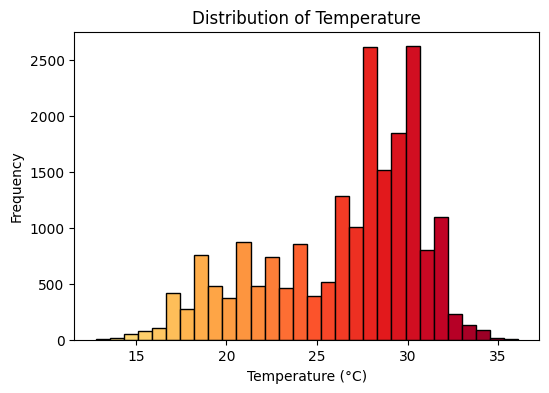

In [8]:
# Histogram
plt.figure(figsize=(6, 4))
counts, bins, patches = plt.hist(
    data['TAVG'],
    bins=30,
    edgecolor='black'
)

# Apply gradient colors
colors = plt.cm.YlOrRd(np.linspace(0.2, 1, len(patches)))

for c, p in zip(colors, patches):
    p.set_facecolor(c)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

In [9]:
# Stationarity Check (ADF Test)
from statsmodels.tsa.stattools import adfuller

result = adfuller(series)
print("p-value:", result[1])

p-value: 1.752534533804143e-23


P value is less than 0.05 , so we reject the null hypothesis , so my time series is stationary
No need of differencing(removing trends),No need to transform data
-> I can directly apply change-point methods

Breakpoint date: 2016-02-15


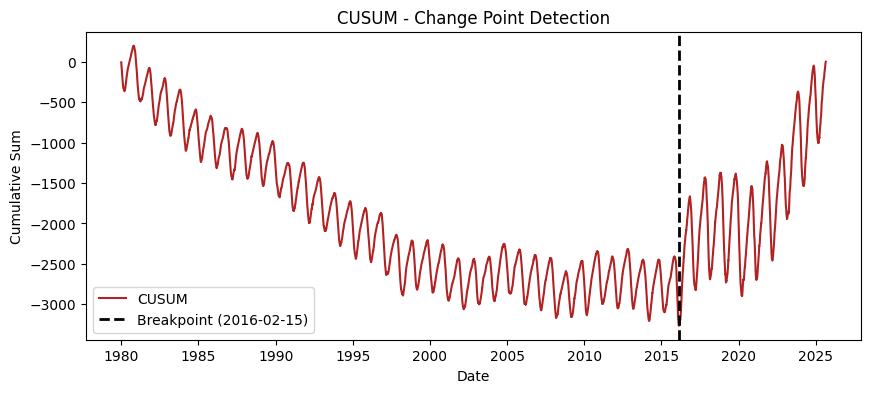

In [10]:
# Compute CUSUM
mean = np.mean(series)
cusum = np.cumsum(series - mean)

# Detect breakpoint
break_index = np.argmax(np.abs(cusum))
break_date = data.loc[break_index, 'DATE']

# Output
print("Breakpoint date:", break_date.date())

# Plot
plt.figure(figsize=(10,4))

# CUSUM line
plt.plot(
    data['DATE'],
    cusum,
    color='firebrick',
    linewidth=1.5,
    label='CUSUM'
)

# Breakpoint line
plt.axvline(
    break_date,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Breakpoint ({break_date.date()})'
)

plt.title("CUSUM - Change Point Detection")
plt.xlabel("Date")
plt.ylabel("Cumulative Sum")
plt.legend()

plt.show()

The curve shows clear oscillations with a downward trend first and then upward recovery. This means:
The mean of the series is not constant over time.This pattern indicates the presence of one or more change-points in the series.

In [11]:
series_small = series.iloc[::5].reset_index(drop=True)
data_small = data.iloc[::5].reset_index(drop=True)

Pettitt Change-point index: 2119
Breakpoint date: 2009-03-15


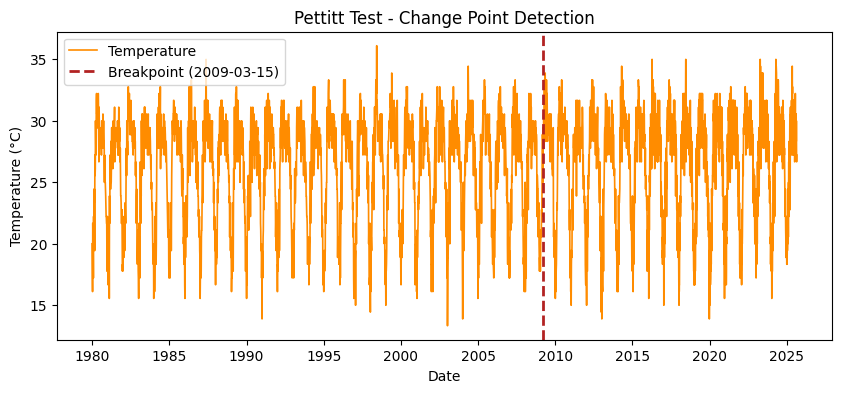

In [12]:
# Pettitt Test - Change Point Detection

def fast_pettitt(x):
    x = np.array(x)
    n = len(x)

    ranks = x.argsort().argsort() + 1
    U = 2*np.cumsum(ranks) - np.arange(1, n+1)*(n+1)

    return np.argmax(np.abs(U)), U

# Apply Pettitt Test
cp_pettit, U = fast_pettitt(series_small.values)

# Get breakpoint date
cp_date = data_small['DATE'].iloc[cp_pettit]

# Output
print("Pettitt Change-point index:", cp_pettit)
print("Breakpoint date:", cp_date.date())

# Plot
plt.figure(figsize=(10,4))

# Temperature series
plt.plot(
    data_small['DATE'],
    series_small,
    color='darkorange',
    linewidth=1.2,
    label='Temperature'
)

# Breakpoint line
plt.axvline(
    cp_date,
    color='firebrick',
    linestyle='--',
    linewidth=2,
    label=f'Breakpoint ({cp_date.date()})'
)

plt.title("Pettitt Test - Change Point Detection")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

In [13]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.4 MB/s eta 0:00:00


Breakpoint indices: [3820, 3910, 3955, 4022]

Breakpoint dates:
2024-03-21
2024-11-12
2025-03-10


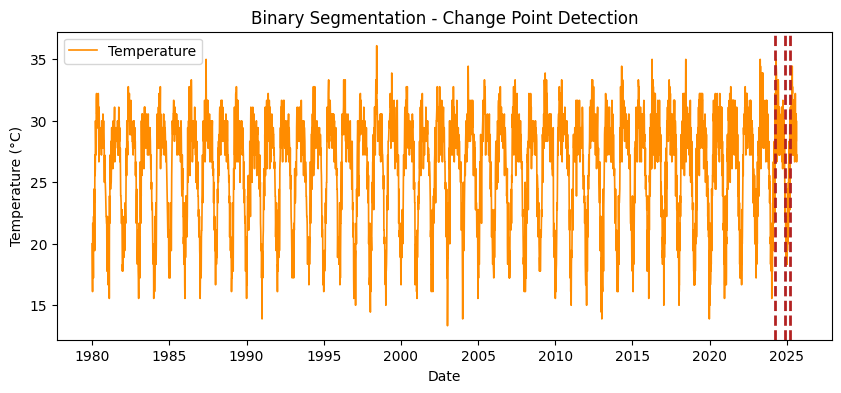

In [14]:
# Binary Segmentation - Change Point Detection
import ruptures as rpt
model = "l2"
algo = rpt.Binseg(model=model).fit(series_small.values)

# Detect breakpoints
breakpoints = algo.predict(n_bkps=3)

print("Breakpoint indices:", breakpoints)

# Convert indices to dates
break_dates = [data_small['DATE'].iloc[i-1]
               for i in breakpoints[:-1]]

print("\nBreakpoint dates:")
for d in break_dates:
    print(d.date())

# Plot
plt.figure(figsize=(10,4))

# Temperature series
plt.plot(
    data_small['DATE'],
    series_small,
    color='darkorange',
    linewidth=1.2,
    label='Temperature'
)

# Breakpoint lines
for bp in breakpoints[:-1]:

    plt.axvline(
        data_small['DATE'].iloc[bp-1],
        color='firebrick',
        linestyle='--',
        linewidth=2
    )

plt.title("Binary Segmentation - Change Point Detection")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

The algorithm found change-points near the end of the data.
This means temperature pattern changed recently.

Breakpoint indices: [1315, 2530, 3235, 4022]

Breakpoint dates:
1998-03-01
2014-10-25
2020-03-14


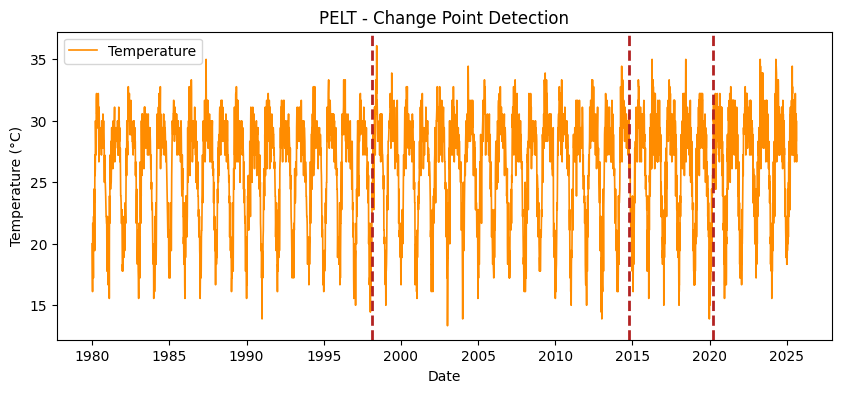

In [15]:
# PELT - Change Point Detection

algo = rpt.Pelt(
    model="l2",
    min_size=700
).fit(series_small.values)

# Detect breakpoints
breakpoints = algo.predict(pen=60)

print("Breakpoint indices:", breakpoints)

# Convert indices to dates
valid_bkps = [bp for bp in breakpoints if bp < len(data_small)]

print("\nBreakpoint dates:")
for bp in valid_bkps:
    print(data_small['DATE'].iloc[bp-1].date())

# Plot
plt.figure(figsize=(10,4))

# Temperature series
plt.plot(
    data_small['DATE'],
    series_small,
    color='darkorange',
    linewidth=1.2,
    label='Temperature'
)

# Breakpoint lines
for bp in valid_bkps:

    plt.axvline(
        data_small['DATE'].iloc[bp-1],
        color='firebrick',
        linestyle='--',
        linewidth=2
    )

plt.title("PELT - Change Point Detection")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

Breakpoint date: 2025-03-10


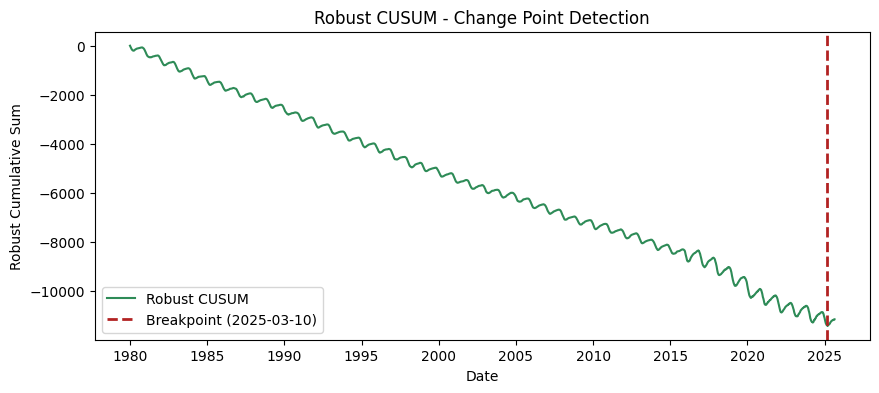

In [16]:
# Robust CUSUM - Change Point Detection

# Robust statistics
median = np.median(series)
mad = np.median(np.abs(series - median))

# Robust CUSUM
robust_cusum = np.cumsum((series - median) / mad)

# Detect breakpoint
break_index = np.argmax(np.abs(robust_cusum))
break_date = data.loc[break_index, 'DATE']

# Output
print("Breakpoint date:", break_date.date())

# Plot
plt.figure(figsize=(10,4))

# Robust CUSUM line
plt.plot(
    data['DATE'],
    robust_cusum,
    color='seagreen',
    linewidth=1.5,
    label='Robust CUSUM'
)

# Breakpoint line
plt.axvline(
    break_date,
    color='firebrick',
    linestyle='--',
    linewidth=2,
    label=f'Breakpoint ({break_date.date()})'
)

plt.title("Robust CUSUM - Change Point Detection")
plt.xlabel("Date")
plt.ylabel("Robust Cumulative Sum")
plt.legend()

plt.show()

The Robust CUSUM plot shows a steady downward trend, indicating a gradual shift in temperature relative to the median, with no abrupt structural breaks but consistent deviation over time.

Number of anomalies detected: 913


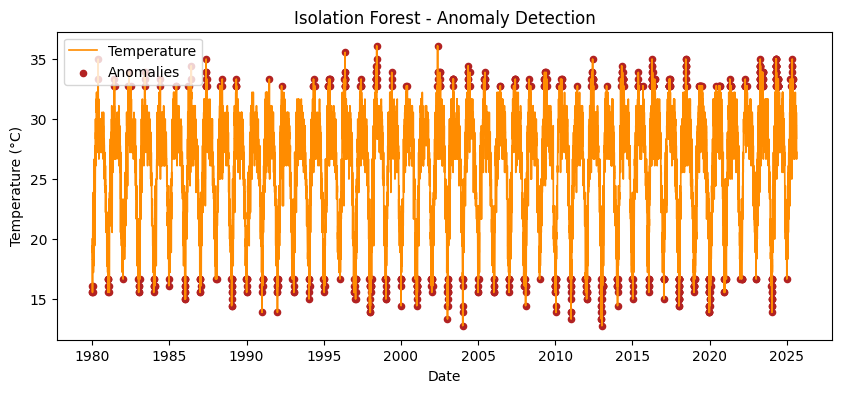

In [17]:
# Isolation Forest - Anomaly Detection

from sklearn.ensemble import IsolationForest

# Prepare data
X = series.values.reshape(-1, 1)

# Fit Isolation Forest
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

data['anomaly'] = model.fit_predict(X)

# Extract anomaly indices
anomalies = np.where(data['anomaly'] == -1)[0]

# Anomaly dates
anomaly_dates = data['DATE'].iloc[anomalies]

print("Number of anomalies detected:", len(anomalies))

# Plot
plt.figure(figsize=(10,4))

# Temperature series
plt.plot(
    data['DATE'],
    series.values,
    color='darkorange',
    linewidth=1.2,
    label='Temperature'
)

# Highlight anomalies
plt.scatter(
    anomaly_dates,
    series.values[anomalies],
    color='firebrick',
    s=20,
    label='Anomalies'
)

plt.title("Isolation Forest - Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

“The detected change-points are highly concentrated in a specific region, indicating increased variability in the temperature series during that period, although some detections may be due to seasonal fluctuations rather than true structural changes.”

In [18]:
# Before and After Change Point Analysis
# Pettitt breakpoint date
bp_date = pd.to_datetime("2009-03-15")

# Split data
before = data[data['DATE'] < bp_date]['TAVG']
after  = data[data['DATE'] >= bp_date]['TAVG']

# Summary statistics
print("Before Change Point")
print("-------------------")
print("Mean :", round(before.mean(), 2))
print("Std  :", round(before.std(), 2))

print("\nAfter Change Point")
print("-------------------")
print("Mean :", round(after.mean(), 2))
print("Std  :", round(after.std(), 2))

Before Change Point
-------------------
Mean : 26.25
Std  : 4.27

After Change Point
-------------------
Mean : 26.88
Std  : 4.39


Forecasting

Pettitt Change-point: 2009-03-15

SARIMAX Performance
-------------------
MAE  : 1.021
RMSE : 1.25
MAPE : 3.864 %

Naive Forecast MAE: 1.953


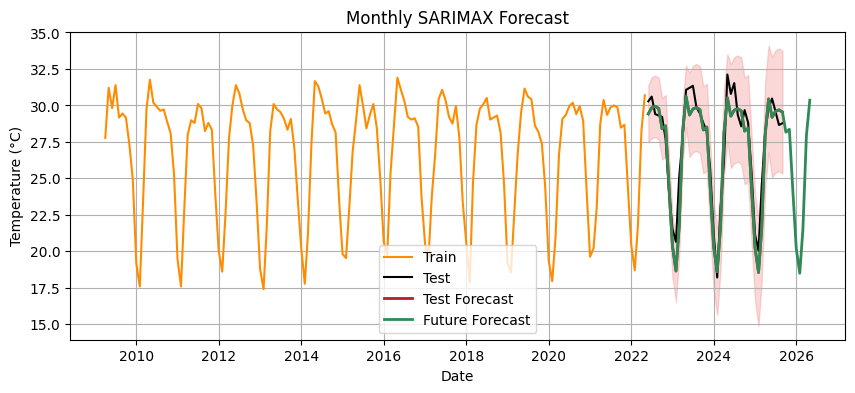

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# -----------------------------------
# STEP 1: Pettitt Change-point
# -----------------------------------

def fast_pettitt(x):
    x = np.array(x)
    n = len(x)

    ranks = x.argsort().argsort() + 1
    U = 2*np.cumsum(ranks) - np.arange(1, n+1)*(n+1)

    return np.argmax(np.abs(U))

cp_pettit = fast_pettitt(series_small.values)

cp_date = data_small['DATE'].iloc[cp_pettit]

print("Pettitt Change-point:", cp_date.date())

# -----------------------------------
# STEP 2: Segment data
# -----------------------------------

series_final = series_small.iloc[cp_pettit:]
data_final = data_small.iloc[cp_pettit:].reset_index(drop=True)

series_final.index = pd.to_datetime(data_final['DATE'])

# -----------------------------------
# STEP 3: Convert to Monthly
# -----------------------------------

series_monthly = series_final.resample('ME').mean()
series_monthly = series_monthly.asfreq('ME')

# -----------------------------------
# STEP 4: Train-Test Split
# -----------------------------------

train_size = int(len(series_monthly) * 0.8)

train = series_monthly[:train_size]
test  = series_monthly[train_size:]

# -----------------------------------
# STEP 5: Fit SARIMAX
# -----------------------------------

model = SARIMAX(
    train,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit(disp=False)

# -----------------------------------
# STEP 6: Forecast Test
# -----------------------------------

forecast_obj = fit.get_forecast(steps=len(test))

forecast_test = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# -----------------------------------
# STEP 7: Evaluation
# -----------------------------------

df_eval = pd.concat([test, forecast_test], axis=1)
df_eval.columns = ['Actual', 'Forecast']
df_eval = df_eval.dropna()

mae  = mean_absolute_error(df_eval['Actual'],
                           df_eval['Forecast'])

rmse = np.sqrt(np.mean(
    (df_eval['Actual'] - df_eval['Forecast'])**2
))

mape = np.mean(
    np.abs(
        (df_eval['Actual'] - df_eval['Forecast'])
        / df_eval['Actual']
    )
) * 100

print("\nSARIMAX Performance")
print("-------------------")
print("MAE  :", round(mae, 3))
print("RMSE :", round(rmse, 3))
print("MAPE :", round(mape, 3), "%")

# -----------------------------------
# STEP 8: Naive Forecast
# -----------------------------------

naive_forecast = test.shift(1)

df_naive = pd.concat([test, naive_forecast], axis=1)
df_naive.columns = ['Actual', 'Naive']
df_naive = df_naive.dropna()

mae_naive = mean_absolute_error(
    df_naive['Actual'],
    df_naive['Naive']
)

print("\nNaive Forecast MAE:", round(mae_naive, 3))

# -----------------------------------
# STEP 9: Future Forecast
# -----------------------------------

future_obj = fit.get_forecast(steps=48)

forecast_future = future_obj.predicted_mean
future_conf = future_obj.conf_int()

# -----------------------------------
# STEP 10: Plot
# -----------------------------------

plt.figure(figsize=(10,4))

# Train
plt.plot(
    train.index,
    train,
    color='darkorange',
    label='Train'
)

# Test
plt.plot(
    test.index,
    test,
    color='black',
    label='Test'
)

# Test Forecast
plt.plot(
    forecast_test.index,
    forecast_test,
    color='firebrick',
    linewidth=2,
    label='Test Forecast'
)

# Confidence interval
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color='lightcoral',
    alpha=0.3
)

# Future Forecast
plt.plot(
    forecast_future.index,
    forecast_future,
    color='seagreen',
    linewidth=2,
    label='Future Forecast'
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Monthly SARIMAX Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
comparison = pd.DataFrame({
    'Actual': test.values,
    'Forecast': forecast_test.values
}, index=test.index)

print(comparison.head(10))

               Actual   Forecast
DATE                            
2022-05-31  30.277778  29.422987
2022-06-30  30.601852  29.835647
2022-07-31  29.401709  29.938714
2022-08-31  29.305556  29.787013
2022-09-30  29.212963  28.397022
2022-10-31  27.692308  28.597629
2022-11-30  24.120370  24.470124
2022-12-31  21.527778  20.360805
2023-01-31  20.648148  18.652447
2023-02-28  25.046296  21.699584
